In [299]:
import numpy as np
from numpy.polynomial.hermite import hermgauss
import math
from scipy.special import eval_hermite
from matplotlib import pyplot as plt

In [343]:
plt.rcParams.update({
    'text.usetex': False,
    'mathtext.fontset': 'cm',
    'font.family': 'serif',
})

In [426]:
hbarc = 197.3269804
v_r = 200 # MeV
k_r = 1.487 # fm^(-2)
v_t = -178 # MeV
k_t = .639 # fm^(-2)
v_s = -91.85 # MeV
k_s = .465 # fm^(-2)
mu = 469.459 #MeV
nu = 0.11 # fm^(-2)
hbar_omega = 2 * hbarc**2 * nu / mu

In [492]:
def log_normalization_const_squared(nu, n):
    log_normalization_const_squared = np.log(np.sqrt(2 * nu))
    log_normalization_const_squared -= np.log(np.pow(np.pi, 1/2)) 
    log_normalization_const_squared -= np.log(2) * (2*n)
    log_normalization_const_squared -= math.lgamma(2 * n + 2)
    return log_normalization_const_squared

def kinetic_energy(n_basis, hbarc):
    diag = [hbarc * n + 3/4 * hbarc for n in range(0, n_basis)]
    kinetic_energy = np.diag(diag)
    off_diagonal = np.zeros((n_basis, n_basis))
    for n in range(n_basis):
        if n > 0:
            off_diagonal[n, n-1] -= hbarc/4 * np.sqrt(n * (n + 1/2))
            off_diagonal[n-1, n] = off_diagonal[n, n-1]
        if n + 1 < n_basis:
            off_diagonal[n, n+1] -= hbarc/4 * np.sqrt((n+1) * (n + 3/2))
            off_diagonal[n+1, n] = off_diagonal[n, n+1]
    kinetic_energy += off_diagonal 
    return kinetic_energy

def modified_hermite_polynomial(x, eta, d1, d2):
    return eval_hermite(d1, eta * x) * eval_hermite(d2, eta * x)


def potential_energy_entry(v, k, n, m, nu):
    eta = 1/np.sqrt(1 + k/(2*nu))
    points, weights = hermgauss(m + n + 2)
    gauss_hermite = np.sum(weights * modified_hermite_polynomial(points, eta, 2*m+1, 2*n+1))
    norm = np.sqrt(np.exp(log_normalization_const_squared(nu, n) + log_normalization_const_squared(nu, m)))
    entry = norm * eta / (2 * np.sqrt(2*nu)) * v * gauss_hermite
    return entry

def potential_energy(v, k, nu, n_basis):
    potential_matrix = np.fromfunction(np.vectorize(lambda n, m: potential_energy_entry(v, k , n, m, nu)), (n_basis, n_basis), dtype = int)
    return potential_matrix

def spins_swap_operator():
    return np.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, -1], [0, 0, -1, 0]])

def spin_squared_operator():
    return np.array([[2, 0, 0, 0], [0, 2, 0, 0], [0, 0, 1, 1], [0, 0, 1, 1]])

def isospin_squared_operator():
    return np.array([[0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 1, -1], [0, 0, -1, 1]])

def hamiltonian(n_basis, v_r, k_r, v_t, k_t, v_s, k_s, nu, hbar_omega):
    id = np.diag([1, 1, 1, 1])
    p = spins_swap_operator()
    hamiltonian = \
        np.kron(id, kinetic_energy(n_basis, hbar_omega)) + \
        np.kron(id, potential_energy(v_r, k_r, nu, n_basis)) + \
        np.kron(1/2 * (id + p), potential_energy(v_t, k_t, nu, n_basis)) + \
        np.kron(1/2 * (id - p), potential_energy(v_s, k_s, nu, n_basis)) 
    return hamiltonian

def exp_fit(x, a, b, c):
    return a * np.exp(-b * x) + c


In [456]:
h = hamiltonian(5, v_r, k_r, v_t, k_t, v_s, k_s, nu, hbar_omega)

for row in h:
    print(' '.join(f'{e:.3f}' for e in row))

-0.132 -0.028 -7.866 4.999 -2.723 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000
-0.028 21.956 -12.515 -5.756 3.850 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000
-7.866 -12.515 43.224 -23.866 -4.371 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000
4.999 -5.756 -23.866 63.238 -34.274 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000
-2.723 3.850 -4.371 -34.274 82.503 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000
0.000 0.000 0.000 0.000 0.000 -0.132 -0.028 -7.866 4.999 -2.723 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000
0.000 0.000 0.000 0.000 0.000 -0.028 21.956 -12.515 -5.756 3.850 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000
0.000 0.000 0.000 0.000 0.000 -7.866 -12.515 43.224 -23.866 -4.371 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.0

In [503]:
from scipy.optimize import curve_fit

M = np.arange(1, 51, 1)
energies = []

for n_basis in M:
    h = hamiltonian(n_basis, v_r, k_r, v_t, k_t, v_s, k_s, nu, hbar_omega)
    # exploit the fact that the hamiltonian is block-diagonal
    h_1 = h[0:n_basis, 0:n_basis]
    h_2 = h[n_basis:2*n_basis, n_basis:2*n_basis]
    h_3 = h[2*n_basis:4*n_basis, 2*n_basis:4*n_basis]
    eigenvalues_1, eigenvectors_1 = np.linalg.eigh(h_1)
    eigenvalues_2, eigenvectors_2 = np.linalg.eigh(h_2)
    eigenvalues_3, eigenvectors_3= np.linalg.eigh(h_3)
    # normalized
    eigenvectors_1 /= np.sqrt(np.sum(np.pow(eigenvectors_1, 2)))
    eigenvectors_2 /= np.sqrt(np.sum(np.pow(eigenvectors_2, 2)))
    eigenvectors_3 /= np.sqrt(np.sum(np.pow(eigenvectors_3, 2)))
    # take minimum
    eigenvalues = np.append(eigenvalues_1, np.append(eigenvalues_2, eigenvalues_3))
    energies.append(eigenvalues[np.argmin(eigenvalues)])

    if np.argmin(eigenvalues) == 0:
        s = np.array([1,0,0,0])
        iso = np.array([1,0,0,0])
    elif np.argmin(eigenvalues) == 1:
        s = np.array([0,1,0,0])
        iso = np.array([0,1,0,0])
    else:
        s = np.array([0, 0, np.sqrt(np.sum(np.pow(eigenvectors_3[:n_basis], 2))), np.sqrt(np.sum(np.pow(eigenvectors_3[n_basis:], 2)))])
        iso = np.array([0, 0, np.sqrt(np.sum(np.pow(eigenvectors_3[:n_basis], 2))), np.sqrt(np.sum(np.pow(eigenvectors_3[n_basis:], 2)))])
    
    spin_value = s.T @ spin_squared_operator() @ s
    isospin_value = iso.T @ isospin_squared_operator() @ iso

    print(f"n_basis={n_basis:3d}, E={eigenvalues[np.argmin(eigenvalues)]:.4f} MeV nu={nu:.3f} fm^-2 spin = {spin_value:.1f} isospin = {isospin_value:.1f}")

n_basis=  1, E=-0.1318 MeV nu=0.110 fm^-2 spin = 2.0 isospin = 0.0
n_basis=  2, E=-0.1318 MeV nu=0.110 fm^-2 spin = 2.0 isospin = 0.0
n_basis=  3, E=-1.7505 MeV nu=0.110 fm^-2 spin = 2.0 isospin = 0.0
n_basis=  4, E=-1.7565 MeV nu=0.110 fm^-2 spin = 2.0 isospin = 0.0
n_basis=  5, E=-1.9702 MeV nu=0.110 fm^-2 spin = 2.0 isospin = 0.0
n_basis=  6, E=-2.0023 MeV nu=0.110 fm^-2 spin = 2.0 isospin = 0.0
n_basis=  7, E=-2.0267 MeV nu=0.110 fm^-2 spin = 2.0 isospin = 0.0
n_basis=  8, E=-2.0697 MeV nu=0.110 fm^-2 spin = 2.0 isospin = 0.0
n_basis=  9, E=-2.0704 MeV nu=0.110 fm^-2 spin = 2.0 isospin = 0.0
n_basis= 10, E=-2.1091 MeV nu=0.110 fm^-2 spin = 2.0 isospin = 0.0
n_basis= 11, E=-2.1097 MeV nu=0.110 fm^-2 spin = 2.0 isospin = 0.0
n_basis= 12, E=-2.1390 MeV nu=0.110 fm^-2 spin = 2.0 isospin = 0.0
n_basis= 13, E=-2.1407 MeV nu=0.110 fm^-2 spin = 2.0 isospin = 0.0
n_basis= 14, E=-2.1610 MeV nu=0.110 fm^-2 spin = 2.0 isospin = 0.0
n_basis= 15, E=-2.1629 MeV nu=0.110 fm^-2 spin = 2.0 isospin =

Covariance matrix:
0.152 0.011 0.000
0.011 0.001 0.000
0.000 0.000 0.000


/var/folders/xt/ywfmhbp57fn29k3qjqj6frkh0000gn/T/ipykernel_63024/3495907293.py:55: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x) + c


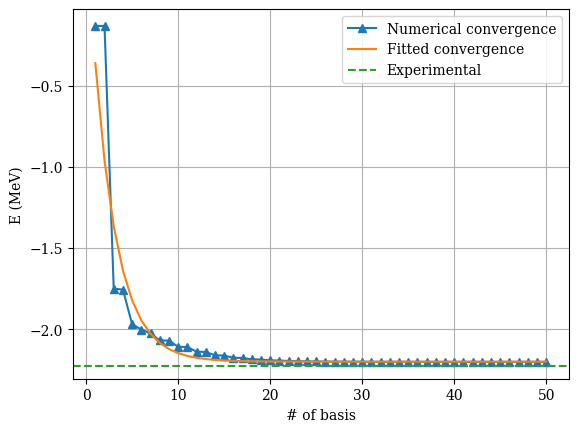

In [489]:
energies = np.array(energies)
# fit with exponential
popt, pcov = curve_fit(exp_fit, M, energies, sigma = 1/np.pow(M,1))
print('Covariance matrix:')
for row in pcov:
    print(' '.join(f'{e:.3f}' for e in row))

cmap = plt.get_cmap('tab20')
plt.plot(M, energies, '-^', color = cmap(0), label = 'Numerical convergence')
plt.plot(M, exp_fit(M, popt[0], popt[1], popt[2]), '-', color = cmap(2), label = f'Fitted convergence ')
plt.axhline(-2.2246, color = cmap(4), linestyle = 'dashed', label = 'Experimental')
plt.xlabel('# of basis')
plt.ylabel('E (MeV)')
plt.legend()
plt.grid()
plt.savefig('imgs/assignment 2/basis_convergence.pdf', bbox_inches='tight')
plt.show()

In [494]:
popt[2]

np.float64(-2.2001446454289315)

n_basis= 10, E=-0.2082 MeV nu=0.010 fm^-2
n_basis= 10, E=-1.1836 MeV nu=0.020 fm^-2
n_basis= 10, E=-1.7626 MeV nu=0.030 fm^-2
n_basis= 10, E=-2.0016 MeV nu=0.040 fm^-2
n_basis= 10, E=-2.0804 MeV nu=0.050 fm^-2
n_basis= 10, E=-2.0989 MeV nu=0.060 fm^-2
n_basis= 10, E=-2.0999 MeV nu=0.070 fm^-2
n_basis= 10, E=-2.0991 MeV nu=0.080 fm^-2
n_basis= 10, E=-2.1007 MeV nu=0.090 fm^-2
n_basis= 10, E=-2.1045 MeV nu=0.100 fm^-2
n_basis= 10, E=-2.1091 MeV nu=0.110 fm^-2
n_basis= 10, E=-2.1132 MeV nu=0.120 fm^-2
n_basis= 10, E=-2.1159 MeV nu=0.130 fm^-2
n_basis= 10, E=-2.1164 MeV nu=0.140 fm^-2
n_basis= 10, E=-2.1145 MeV nu=0.150 fm^-2
n_basis= 10, E=-2.1099 MeV nu=0.160 fm^-2
n_basis= 10, E=-2.1029 MeV nu=0.170 fm^-2
n_basis= 10, E=-2.0934 MeV nu=0.180 fm^-2
n_basis= 10, E=-2.0816 MeV nu=0.190 fm^-2
n_basis= 10, E=-2.0678 MeV nu=0.200 fm^-2
n_basis= 10, E=-2.0521 MeV nu=0.210 fm^-2
n_basis= 15, E=-0.6892 MeV nu=0.010 fm^-2
n_basis= 15, E=-1.7404 MeV nu=0.020 fm^-2
n_basis= 15, E=-2.0492 MeV nu=0.03

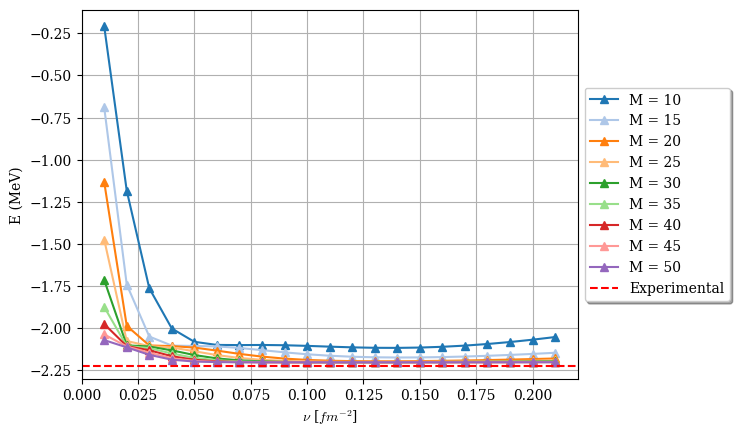

In [496]:
nus = np.arange(0.01, 0.22, 0.01)
M = np.arange(10, 55, 5) 
energies = np.zeros((len(M), len(nus)))
i = 0

for n_basis in M:
    j = 0
    for n in nus:
        _hbar_omega = 2 * hbarc**2 * n / mu
        # exploit the fact that the hamiltonian is block-diagonal
        h = hamiltonian(n_basis, v_r, k_r, v_t, k_t, v_s, k_s, n, _hbar_omega)
        h_1 = h[0:n_basis, 0:n_basis]
        h_2 = h[n_basis:2*n_basis, n_basis:2*n_basis]
        h_3 = h[2*n_basis:4*n_basis, 2*n_basis:4*n_basis]
        eigenvalues = np.append(np.linalg.eigvalsh(h_1), np.append(np.linalg.eigvalsh(h_2), np.linalg.eigvalsh(h_3)))
        energies[i, j] = eigenvalues[np.argmin(eigenvalues)]
        print(f"n_basis={n_basis:3d}, E={eigenvalues[0]:.4f} MeV nu={n:.3f} fm^-2")
        j += 1
    i += 1

i = 0
cmap = plt.get_cmap('tab20')
for row in energies:
    color = cmap(i)
    plt.plot(nus, row, '-^', color = color, label = f'M = {M[i]}')
    i += 1

plt.axhline(-2.2246, color='r', linestyle='dashed', label='Experimental')
plt.xlabel(r'$\nu$ [$fm^{-2}$]')
plt.ylabel('E (MeV)')
plt.legend(loc = 'center left', ncols = 1, bbox_to_anchor=(1, 0.5), fancybox = True, shadow = True)
plt.grid()
plt.savefig('imgs/assignment 2/vu_insensibility.pdf', bbox_inches='tight')
plt.show()

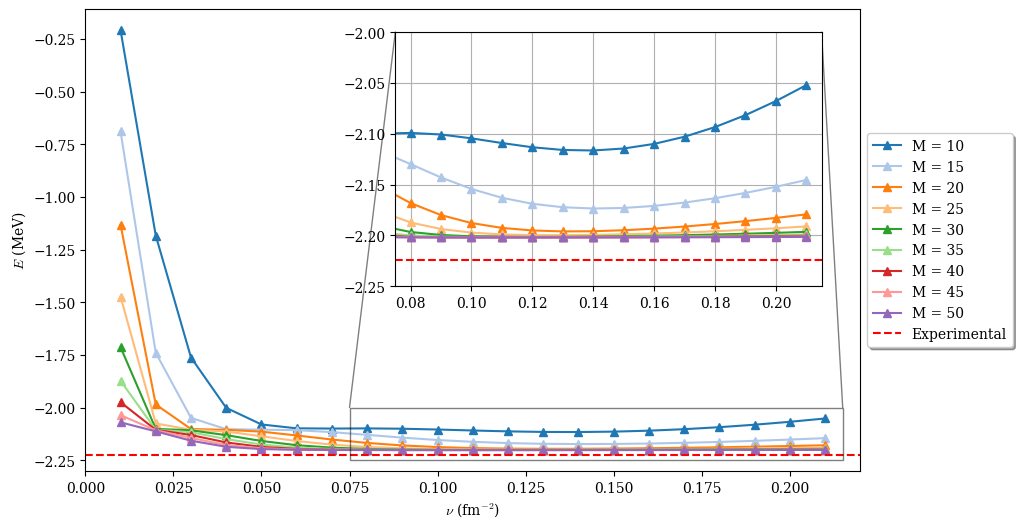

In [497]:
fig, ax = plt.subplots(figsize=(10, 6))

# Main plot
i = 0
cmap = plt.get_cmap('tab20')
for row in energies:
    color = cmap(i)
    ax.plot(nus, row, '-^', color = color, label = f'M = {M[i]}')
    i += 1
ax.axhline(-2.2246, color='r', linestyle='dashed', label='Experimental')
ax.set_xlabel(r'$\nu$ (fm$^{-2}$)')
ax.set_ylabel(r'$E$ (MeV)')
ax.legend(loc = 'center left', ncols = 1, bbox_to_anchor=(1, 0.5), fancybox = True, shadow = True)

# Inset
ax_inset = ax.inset_axes([0.4, 0.4, 0.55, 0.55])  # [x, y, width, height] in axes coordinates
i = 0
for row in energies:
    color = cmap(i)
    ax_inset.plot(nus, row, '-^', color = color, label = f'M = {M[i]}')
    i += 1
ax_inset.axhline(-2.2246, color='r', linestyle='dashed')
ax_inset.set_xlim(0.075, 0.215)   # zoom region
ax_inset.set_ylim(-2.25, -2)
ax_inset.grid()

# Draw lines connecting inset to main plot
ax.indicate_inset_zoom(ax_inset, edgecolor='black')
plt.savefig('imgs/assignment 2/vu_insensibility_inset.pdf', bbox_inches='tight')
plt.show()

In [498]:
M[np.unravel_index(energies.argmin(), energies.shape)[0]]

np.int64(50)

In [499]:
nus[np.unravel_index(energies.argmin(), energies.shape)[0]]

np.float64(0.09)

In [500]:
np.min(energies)

np.float64(-2.2019899087898422)